# Compute Derivative and laplacian

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline , make_interp_spline

In [71]:
def f(x,order):
    order = int(order)
    if order == 0:
        return np.exp(-np.power(x,2))
    elif order == 1:
        return -2*x*f(x,0)
    elif order == 2:
        return -2*f(x,0) + 4*np.power(x,2)*f(x,0)
    else:
        print("Invalid order!")
        return np.zeros(len(x),dtype=float)    

def g(x,order):
    order = int(order)
    if order == 0:
        return np.exp(-np.power(x,2))*np.sin(x)
    elif order == 1:
        return np.exp(-np.power(x,2))*(np.cos(x) - 2*x*np.sin(x))
    elif order == 2:
        return np.exp(-np.power(x,2))*(-4*x*np.cos(x)+(-3+4*np.power(x,2))*np.sin(x))
    else:
        print("Invalid order!")
        return np.zeros(len(x),dtype=float)  

def A(x,order):
    order = int(order)
    if order == 0:
        return np.exp(-np.power(x,2))*np.cos(x)
    elif order == 1:
        return -np.exp(-np.power(x,2))*(2*x*np.cos(x) + np.sin(x))
    elif order == 2:
        return np.exp(-np.power(x,2))*((4*np.power(x,2)-3)*np.cos(x)+4*x*np.sin(x))
    else:
        print("Invalid order!")
        return np.zeros(len(x),dtype=float)  

def R(x,order):
    order = int(order)
    if order == 0:
        return np.exp(np.cos(x))
    elif order == 1:
        return -R(x,0)*np.sin(x)
    elif order == 2:
        return R(x,0)*(-np.cos(x) + np.power(np.sin(x),2))
    else:
        print("Invalid order!")
        return np.zeros(len(x),dtype=float)  

In [72]:
eta = 0.0

def laplacian_numpy(func,x):
    """ compute first and second derivatives """
    first = np.gradient(func,x,edge_order=2)
    second = np.gradient(first,x,edge_order=2)
    first[0] = 0.0
    """ apply boundary conditions """
    return second + first/(x+eta)

def analytical(x,func):
    if func == "f":
        return 4*f(x,0)*(np.power(x,2) - 1)
    elif func == "g":
        c1 = np.cos(x)/x * (1-4*np.power(x,2))
        c2 = np.sin(x)*(4*np.power(x,2)-5)
        return np.exp(-np.power(x,2))*(c1+c2)
    elif func == "A":
        c1 = np.cos(x) * (-5+4*np.power(x,2))
        c2 = np.sin(x)/x *(4*np.power(x,2)-1)
        return np.exp(-np.power(x,2))*(c1+c2)
    elif func == "R":
        c1 = np.cos(x) + np.sin(x)/x - np.power(np.sin(x),2)
        return -R(x,0)*c1
    else:
        print("Invalid function!!")
        return x*0.0


""" compute derivative """

# without extrapolation
def derivative_rui(func,x,order,extrapolate,k):
    order = int(order)
    # compute step
    step = x[1] - x[0]
    # pad array
    Npad = 2
    pad = np.pad(func,(Npad,Npad), mode='constant' , constant_values = (func[0],func[-1]))
    N = len(func)
    # compute derivative 1st order
    if order == 1:
        # 5-point derivative
        first = (pad[Npad-2:Npad+N-2] - 8*pad[Npad-1:Npad+N-1] + 8*pad[Npad+1:Npad+N+1] - pad[Npad+2:Npad+N+2])/12
        if extrapolate:
            first = first/step
            first = extrapolate_derivative(x,first,k)
            return first
        else:
            # compute edges using second order approximation
            first[0] = -3/2*func[0] + 2*func[1] - 0.5*func[2]
            first[-1] = 3/2*func[-1] - 2*func[-2] + 0.5*func[-3]
            # compute near-edge using 3-point derivative
            first[1] = (func[2] - func[0])/2
            first[-2] = (func[-1] - func[-3])/2
            return first/step
    # compute second order derivative
    elif order == 2:
        # 5-point derivative
        second = (-pad[Npad-2:Npad+N-2] + 16*pad[Npad-1:Npad+N-1] - 30*pad[Npad:Npad+N] + 16*pad[Npad+1:Npad+N+1] - pad[Npad+2:Npad+N+2])/12
        if extrapolate:
            second = second/step**2
            second = extrapolate_derivative(x,second,k)
            return second
        else:
            # compute edges using 2-order approximation
            second[0] = 0.5*func[2] - func[1] + 0.5*func[0]
            second[-1] = 0.5*func[-1] - func[-2] + 0.5*func[-3]
            # compute near-edge using 3-point derivative
            second[1] = func[2] - 2*func[1] + func[0]
            second[-2] = func[-1] - 2*func[-2] + func[-3]
            return second/step**2
    else:
        print("Invalid order!")
        return np.zeros(len(x),dtype=float)   

def extrapolate_derivative(x,derivative,k):
    N = len(derivative)

    spline = make_interp_spline(x[2:N-2], derivative[2:N-2],k = k)

    derivative[0:2] = spline(x[0:2])
    derivative[N-2:N] = spline(x[N-2:N])

    return derivative


def laplacian_rui(func,x):

    """ compute first derivative """
    first = derivative_rui(func,x,1,False,9)

    """ compute second derivative """
    second = derivative_rui(func,x,2,False,9)

    """ compute laplacian """
    laplacian = second + first/x

    """ extrapolate edges """
    laplacian = extrapolate_derivative(x,laplacian,9)

    return laplacian
    
    

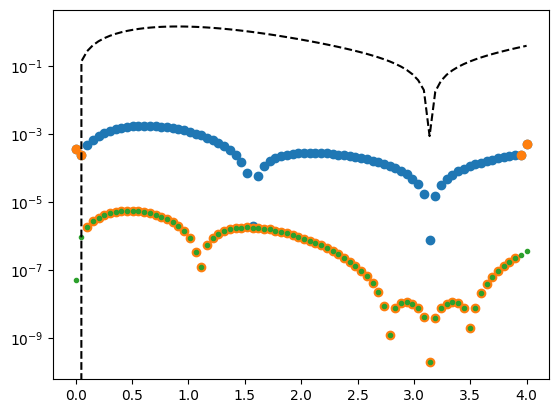

In [73]:
x = np.linspace(0.0,4,80)
func = R(x,0)
z = R(x,1)

y = derivative_rui(func,x,1,False,9)
test = derivative_rui(func,x,1,True,9)

LN = np.gradient(func,x,edge_order=2)
plt.scatter(x,np.abs((LN-z)))
plt.scatter(x,np.abs((y-z)))
plt.scatter(x,np.abs((test-z)),marker = ".")
plt.plot(x,np.abs((z)),color = "black" , ls = "dashed")
plt.yscale("log")
plt.show()

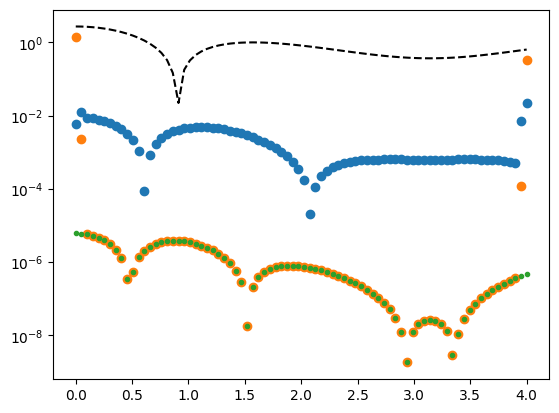

In [74]:
x = np.linspace(0.0,4,80)
func = R(x,0)
z = R(x,2)

y = derivative_rui(func,x,2,False,9)
test = derivative_rui(func,x,2,True,9)

LN = np.gradient(np.gradient(func,x,edge_order=2),x,edge_order=2)
plt.scatter(x,np.abs((LN-z)))
plt.scatter(x,np.abs((y-z)))
plt.scatter(x,np.abs((test-z)),marker = ".")
plt.plot(x,np.abs((z)),color = "black" , ls = "dashed")
plt.yscale("log")
plt.show()

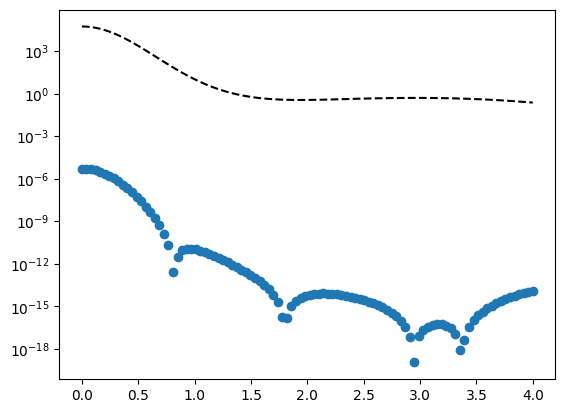

In [79]:
x = np.linspace(1e-10,4,100)
func = R(x,0)
z = np.exp(-analytical(x,"R"))

y = np.exp(-laplacian_rui(func,x))

plt.scatter(x,np.power(y-z,2))
plt.plot(x,np.power(z,2),color = "black" , ls = "dashed")
plt.yscale("log")
plt.show()

# Solve radial equation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bec2DCylindrical.utils as ut
from scipy.integrate import simpson

In [4]:
def potential(x):
    return 0.5*np.power(x,2)

def Hamiltonian(func,x):
    x = np.real(x)
    # return kinetic propagator
    kinetic = -0.5*ut.laplacian(func,x)
    # compute potential propagator
    pot = potential(x)*func
    return kinetic + pot

def ComputeNorm(func,x):
    N = x*func*np.conjugate(func)
    return 2*np.pi*simpson(N,np.real(x))

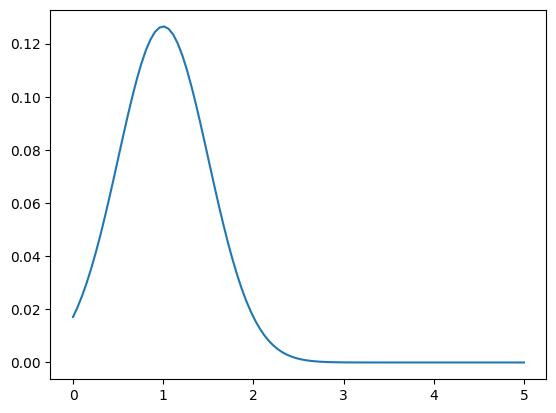

In [6]:
r = np.linspace(1e-10,5,100)
psi0 = np.exp(-np.power(r-1,2)) + 1j*0
psi0 = psi0/np.sqrt(ComputeNorm(np.copy(psi0),r))
plt.plot(np.real(r),np.real(psi0*np.conjugate(psi0)))
plt.show()

In [25]:
def harmonic(x):
    # compute norm factor
    norm = 1/np.sqrt(np.pi)
    phi = norm*np.exp(-np.power(x,2)/2)
    return phi

In [38]:
iterations = 30000
step = 0.001
norms = []

ground = harmonic(r)
psi = np.copy(psi0)
for i in range(0,iterations):
    # Runge-kutta 3-th order
    k0 = -step*Hamiltonian(psi,r)
    k1 = -step*Hamiltonian(psi+k0/2,r)
    k2 = -step*Hamiltonian(psi+2*k1-k0,r)

    psi = psi + (k0 + 4*k1 + k2)/6

    # normalize psi
    psi = psi/np.sqrt(ComputeNorm(np.copy(psi),r))

    if i%100:
        norms.append(np.power(np.abs(psi-ground),2).sum())


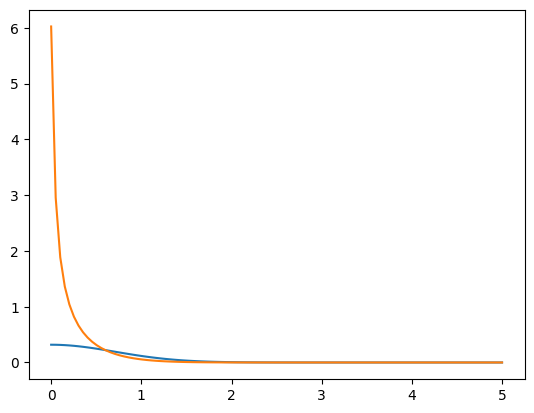

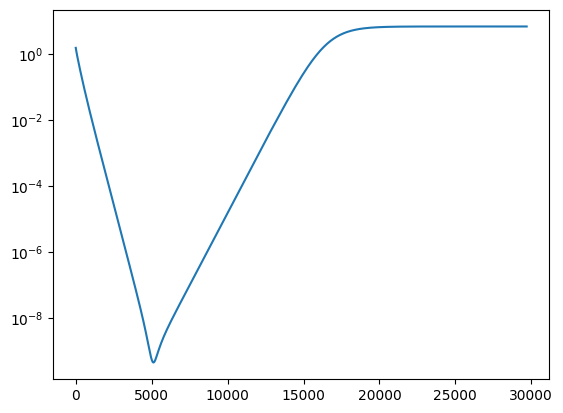

In [ ]:
plt.plot(r,ground*np.conjugate(ground))
plt.plot(r,psi*np.conjugate(psi))
plt.show()

plt.plot(norms)
plt.yscale("log")
plt.show()

In [40]:
1/0.04

25.0